### 1. Cài đặt các thư viện cần thiết

In [1]:
!pip install -q transformers peft bert-score rouge-score datasets requests tqdm pandas openpyxl

### 2. Import thư viện & Thiết lập Seed

In [2]:
import os
import random
import json
import time
import requests
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from IPython.display import display
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel

def seed_everything(seed_value=42):
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    torch.manual_seed(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
    print('Seed đã được thiết lập:', seed_value)

seed_everything(42)

Seed đã được thiết lập: 42


### 3. Cấu hình API Key và Trọng tài LLM

In [12]:
from kaggle_secrets import UserSecretsClient
from google import genai
from google.genai import types
from pydantic import BaseModel, Field
from typing import List

# 1. Khởi tạo và lấy API Key từ Kaggle Secrets
user_secrets = UserSecretsClient()
try:
    GEMINI_API_KEY = user_secrets.get_secret("GEMINI_API_KEY") 
except Exception as e:
    print(f"❌ Không thể lấy API Key từ Kaggle Secrets. Lỗi: {e}")
    GEMINI_API_KEY = None

if GEMINI_API_KEY:
    # 2. Khởi tạo Client
    client = genai.Client(api_key=GEMINI_API_KEY)
    MODEL_NAME = "gemini-3.1-flash-lite" 

    # 3. Tiến hành check API Key bằng một request đơn giản
    print("🔄 Đang kiểm tra Gemini API Key...")
    try:
        response = client.models.generate_content(
            model=MODEL_NAME,
            contents="Hello! Trả lời ngắn gọn 'OK' nếu bạn nhận được tin nhắn này.",
        )
        # Nếu chạy đến đây mà không có lỗi nghĩa là API Key hợp lệ
        print("✅ API Key hợp lệ và hoạt động tốt!")
        print(f"🤖 Phản hồi từ Model: {response.text}")
        
    except Exception as e:
        print("❌ API Key không hợp lệ hoặc đã xảy ra lỗi kết nối!")
        print(f"⚠️ Chi tiết lỗi: {e}")
else:
    print("⏭️ Bỏ qua kiểm tra do không tìm thấy API Key.")

🔄 Đang kiểm tra Gemini API Key...
✅ API Key hợp lệ và hoạt động tốt!
🤖 Phản hồi từ Model: OK


### 4. Thiết lập tập kiểm tra và Danh sách Mô hình


In [4]:
import pandas as pd

# Đọc trực tiếp tập test chứa sẵn kết quả Reranking để tiết kiệm 2 tiếng chạy lại
CSV_PATH = "/kaggle/input/datasets/iceemperoz/test-pred/test_predictions_complete.csv"
test_df = pd.read_csv(CSV_PATH)

print(f"✓ Đã load file test từ CSV: {len(test_df)} mẫu.")
print(f"✓ Các cột hiện tại: {test_df.columns.tolist()}")

MODELS_TO_COMPARE = {
    "BARTpho_Base":  "base_only",
    "BARTpho_SFT":   "/kaggle/input/datasets/iceemperoz/model-data/bartpho-summarization/best-model"
    "Bartpho-rwsft": "/kaggle/input/datasets/iceemperoz/bartpho-rwsft/bartpho-rwsft/adapter"
}


✓ Đã load file test từ CSV: 1344 mẫu.
✓ Các cột hiện tại: ['document_clean', 'summary_clean', 'BARTpho_SFT_Reranking', 'BARTpho_RWSFT_Reranking']


### 5. Sinh bản tóm tắt của mô hình trên tập test mẫu

In [5]:
import gc

tokenizer = AutoTokenizer.from_pretrained("vinai/bartpho-syllable")
# Đảm bảo pad token được cấu hình
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def summarize_batch(model, texts: list, max_len=128, min_len=20) -> list:
    inputs = tokenizer(
        texts, 
        return_tensors="pt", 
        max_length=512, 
        truncation=True, 
        padding=True
    ).to("cuda")
    
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_length=max_len,
            min_length=min_len,
            num_beams=4,
            length_penalty=2.0,
            no_repeat_ngram_size=3,
            early_stopping=True,
        )
    return tokenizer.batch_decode(output_ids, skip_special_tokens=True)

# Sử dụng Batch Inference để tối ưu hóa hiệu năng GPU (tăng tốc 10x - 20x)
BATCH_SIZE = 16  # Bạn có thể tăng lên 32 nếu GPU mạnh

for model_name, adapter_path in MODELS_TO_COMPARE.items():
    print(f"\n⌛ Đang load và sinh tóm tắt cho mô hình: {model_name}...")
    
    # Load base model
    base_model = AutoModelForSeq2SeqLM.from_pretrained("vinai/bartpho-syllable")
    
    # Load adapter
    if adapter_path == "base_only":
        model = base_model.to("cuda")
    else:
        model = PeftModel.from_pretrained(base_model, adapter_path)
        model = model.merge_and_unload().to("cuda")
        
    model.eval()
    
    # Sinh tóm tắt theo batch
    all_texts = test_df["document_clean"].tolist()
    summaries = []
    
    for i in tqdm(range(0, len(all_texts), BATCH_SIZE), desc=model_name):
        batch_texts = all_texts[i : i + BATCH_SIZE]
        batch_sums = summarize_batch(model, batch_texts)
        summaries.extend(batch_sums)
        
    test_df[model_name] = summaries
    
    # Giải phóng bộ nhớ lập tức
    del model
    del base_model
    torch.cuda.empty_cache()
    gc.collect()

print("\n✓ Tất cả mô hình đã hoàn thành việc sinh tóm tắt trên tập test bằng Batch Inference!")



⌛ Đang load và sinh tóm tắt cho mô hình: BARTpho_Base...


Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BARTpho_Base: 100%|██████████| 84/84 [21:41<00:00, 15.50s/it]



⌛ Đang load và sinh tóm tắt cho mô hình: BARTpho_SFT...


Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BARTpho_SFT: 100%|██████████| 84/84 [21:42<00:00, 15.50s/it]



✓ Tất cả mô hình đã hoàn thành việc sinh tóm tắt trên tập test bằng Batch Inference!


### Mục 5b. Inference với TF-IDF Re-ranking 

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

RERANKING_MODELS = {
    "BARTpho_SFT_Reranking": "/kaggle/input/datasets/iceemperoz/model-data/bartpho-summarization/best-model",
    "BARTpho_RWSFT_Reranking": "/kaggle/input/datasets/iceemperoz/bartpho-rwsft/bartpho-rwsft/adapter"
}

def summarize_with_reranking(model, tokenizer, text: str,
                              num_candidates: int = 6,
                              max_len: int = 128,
                              min_len: int = 20) -> str:
    """
    Diverse beam search → 6 ứng viên khác nhau
    TF-IDF cosine similarity với document → chọn ứng viên tốt nhất
    """
    inputs = tokenizer(
        text, return_tensors="pt",
        max_length=512, truncation=True
    ).to("cuda")

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            num_beams            = num_candidates,
            num_beam_groups      = num_candidates // 2,  # 3 groups × 2 beams
            diversity_penalty    = 0.8,
            num_return_sequences = num_candidates,
            max_length           = max_len,
            min_length           = min_len,
            no_repeat_ngram_size = 3,
            early_stopping       = True,
            trust_remote_code    = True, 
        )

    # Giải mã toàn bộ 6 ứng viên
    candidates = [
        tokenizer.decode(ids, skip_special_tokens=True)
        for ids in output_ids
    ]

    # Dùng TF-IDF để chọn câu sát nghĩa văn bản gốc nhất
    try:
        corpus     = [text] + candidates
        vectorizer = TfidfVectorizer(max_features=5000)
        tfidf_mat  = vectorizer.fit_transform(corpus)
        scores     = cosine_similarity(tfidf_mat[0:1], tfidf_mat[1:]).flatten()
        best_idx   = int(np.argmax(scores))
        return candidates[best_idx]
    except Exception:
        return candidates[0]  # Fallback nếu lỗi TF-IDF

# Chạy Reranking trên TOÀN BỘ file test
for model_name, adapter_path in RERANKING_MODELS.items():
    if not os.path.exists(adapter_path):
        print(f"⚠️ Không tìm thấy checkpoint tại {adapter_path}, bỏ qua.")
        continue

    print(f"\n⌛ Đang sinh tóm tắt (Reranking) trên toàn bộ file test: {model_name}...")
    base_model = AutoModelForSeq2SeqLM.from_pretrained("vinai/bartpho-syllable")
    model = PeftModel.from_pretrained(base_model, adapter_path)
    model = model.merge_and_unload().to("cuda")
    model.eval()

    summaries = []
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=model_name):
        summaries.append(
            summarize_with_reranking(model, tokenizer, row["document_clean"])
        )
    test_df[model_name] = summaries

    del model; del base_model
    torch.cuda.empty_cache(); gc.collect()

eval_sample = test_df.sample(EVAL_SIZE, random_state=42).reset_index(drop=True)

df_eval_input = pd.DataFrame({
    "source": eval_sample["document_clean"],
    "reference": eval_sample["summary_clean"]
})

all_model_names = list(MODELS_TO_COMPARE.keys()) + list(RERANKING_MODELS.keys())
for col in all_model_names:
    if col in eval_sample.columns:
        df_eval_input[col] = eval_sample[col]

print("✓ Reranking hoàn thành!")
print(f"✓ df_eval_input có {len(df_eval_input.columns) - 2} mô hình, {len(df_eval_input)} mẫu.")

test_df.to_csv("test_predictions_complete.csv", index=False)

### 6. Cấu hình Prompt Template và Hàm Đánh Giá G-Eval bằng Gemini


In [18]:
from google import genai
import json
import time
from tqdm import tqdm
import numpy as np
import pandas as pd

EVALUATION_PROMPT_TEMPLATE = """
Bạn sẽ được cung cấp một bài báo gốc và 4 bản tóm tắt của nó. Nhiệm vụ của bạn là đánh giá 4 bản tóm tắt này dựa trên 4 tiêu chí khác nhau.
Vui lòng đọc và hiểu kỹ các hướng dẫn này.

Tiêu chí và Các bước đánh giá:

1. Relevance (Sự liên quan).
Tiêu chí: Bản tóm tắt chỉ nên bao gồm những thông tin quan trọng từ tài liệu gốc. Hãy trừ điểm đối với các bản tóm tắt chứa thông tin dư thừa, lặp lại và không cần thiết.
Các bước đánh giá:
1. Đọc kỹ bản tóm tắt và tài liệu gốc.
2. So sánh bản tóm tắt với tài liệu gốc và xác định các ý chính của bài báo.
3. Đánh giá mức độ bản tóm tắt bao quát các ý chính của bài báo, và mức độ chứa thông tin dư thừa hoặc không liên quan.
4. Chấm điểm sự liên quan bằng một số nguyên từ 0 đến 100.

2. Coherence (Tính mạch lạc).
Tiêu chí: Bản tóm tắt phải được cấu trúc và tổ chức tốt. Bản tóm tắt không nên chỉ là một tập hợp các thông tin rời rạc, mà phải được liên kết từ câu này sang câu khác thành một khối thông tin mạch lạc về chủ đề.
Các bước đánh giá:
1. Đọc kỹ bài báo và xác định chủ đề chính cùng các ý chính.
2. Đọc bản tóm tắt và so sánh với bài báo. Kiểm tra xem bản tóm tắt có bao quát chủ đề chính và các ý chính của bài báo hay không, và liệu nó có trình bày chúng theo một trình tự rõ ràng và hợp lý không.
3. Chấm điểm tính mạch lạc theo thang điểm từ 0 đến 100, trong đó 0 là thấp nhất và 100 là cao nhất dựa trên Tiêu chí đánh giá.

3. Consistency (Tính nhất quán).
Tiêu chí: Một bản tóm tắt nhất quán về mặt thực tế chỉ chứa các câu khẳng định được hỗ trợ và suy ra từ tài liệu gốc. Hãy trừ điểm nặng đối với các bản tóm tắt chứa thông tin bịa đặt, sai lệch, hoặc không có trong bài gốc.
Các bước đánh giá:
1. Đọc kỹ bài báo và xác định các sự kiện và chi tiết chính mà nó trình bày.
2. Đọc bản tóm tắt và so sánh với bài báo. Kiểm tra xem bản tóm tắt có chứa bất kỳ lỗi sai sự thật hoặc thông tin nào không được bài báo hỗ trợ hay không.
3. Chấm điểm tính nhất quán từ 0 đến 100 dựa trên Tiêu chí đánh giá.

4. Fluency (Tính trôi chảy).
Tiêu chí: Chất lượng của bản tóm tắt về mặt ngữ pháp, chính tả, dấu câu, cách chọn từ và cấu trúc câu.
- 0-33: Kém. Bản tóm tắt có nhiều lỗi khiến văn bản khó hiểu hoặc đọc nghe rất thiếu tự nhiên.
- 34-66: Khá. Bản tóm tắt có some lỗi ảnh hưởng đến sự rõ ràng hoặc trôi chảy của văn bản, nhưng các ý chính vẫn có thể hiểu được.
- 67-100: Tốt. Bản tóm tắt có rất ít hoặc không có lỗi, hành văn tự nhiên, dễ đọc và dễ theo dõi.
Các bước đánh giá: Đọc bản tóm tắt và đánh giá tính trôi chảy của nó dựa trên các tiêu chí đã cho. Chấm điểm tính trôi chảy bằng một số nguyên từ 0 đến 100.


Dữ liệu:

Văn bản gốc:

{document}

Bản tóm tắt 1:

{summary1}

Bản tóm tắt 2:

{summary2}

Bản tóm tắt 3:

{summary3}

Bản tóm tắt 4:

{summary4}

Đánh giá:
Chỉ cung cấp ĐIỂM SỐ là các số nguyên từ 0 đến 100 cho mỗi tiêu chí, tương ứng với thứ tự của các bản tóm tắt.
Định dạng đầu ra bắt buộc phải là một đối tượng JSON hợp lệ có chứa 4 mảng điểm số cho 'Relevance', 'Coherence', 'Consistency', 'Fluency'.
Ví dụ định dạng:
{{
  "Relevance": [score1, score2, score3, score4],
  "Coherence": [score1, score2, score3, score4],
  "Consistency": [score1, score2, score3, score4],
  "Fluency": [score1, score2, score3, score4]
}}
Không xuất ra gạch đầu dòng, khối mã markdown, hoặc bất kỳ lời giải thích nào khác. Chỉ xuất đúng định dạng JSON được yêu cầu.
"""

import time

def call_geval_judge(document, summaries, max_retries=5):
    prompt = EVALUATION_PROMPT_TEMPLATE.format(
        document=document,
        summary1=summaries[0],
        summary2=summaries[1],
        summary3=summaries[2],
        summary4=summaries[3]
    )
    global client

    for attempt in range(max_retries):
        try:
            response = client.models.generate_content(
                model='gemini-3.1-flash-lite',
                contents=prompt,
                config={"response_mime_type": "application/json"}
            )
            return json.loads(response.text)
        except Exception as e:
            err_str = str(e)
            # Retry nếu gặp 429 hoặc 503
            if "429" in err_str or "503" in err_str:
                wait = 5 * (2 ** attempt)  # 5s, 10s, 20s, 40s, 80s
                print(f"⚠️ Lỗi {('429' if '429' in err_str else '503')} - Thử lại sau {wait}s... (lần {attempt+1}/{max_retries})")
                time.sleep(wait)
            else:
                print(f"❌ Lỗi không thể retry: {e}")
                break

    return {m: [50, 50, 50, 50] for m in ['Relevance', 'Coherence', 'Consistency', 'Fluency']}


def run_geval_pipeline(df_data, geval_models):
    sources_list = df_data['source'].dropna().tolist()
    geval_metrics = ['Relevance', 'Coherence', 'Consistency', 'Fluency']
    score_accumulator = {name: {m: [] for m in geval_metrics} for name in geval_models}
    
    print(f"🤖 Đang bắt đầu đánh giá trên {len(sources_list)} mẫu bằng G-Eval (Gemini)...")
    for idx in tqdm(range(len(sources_list)), desc="[G-EVAL RUNNER]"):
        doc = sources_list[idx]
        
        # Đảm bảo lấy đúng 4 mô hình được cấu hình để gửi đi
        current_summaries = [df_data[name].iloc[idx] for name in geval_models]
        
        json_scores = call_geval_judge(doc, current_summaries)
        
        clean_json_scores = {}
        for k, v in json_scores.items():
            clean_json_scores[k.lower().strip()] = v

        for i, name in enumerate(geval_models):
            for m in geval_metrics:
                metric_key = m.lower()
                try:
                    score = clean_json_scores[metric_key][i]
                    score_accumulator[name][m].append(float(score))
                except Exception:
                    score_accumulator[name][m].append(50.0)
        time.sleep(5.0) 
            
    geval_report_rows = []
    for m in geval_metrics:
        row = {"Tiêu chí đánh giá (G-Eval Metrics)": m}
        for name in geval_models:
            row[name] = np.mean(score_accumulator[name][m])
        geval_report_rows.append(row)
        
    return pd.DataFrame(geval_report_rows)


### 7. Thực Thi & Hiển Thị Báo Cáo Kết Quả G-Eval


In [19]:
# Trích xuất 30 mẫu ngẫu nhiên từ test_df (đã có đủ kết quả 4 mô hình) để làm tập mẫu G-Eval
EVAL_SIZE_GEVAL = 30
eval_sample_geval = test_df.sample(EVAL_SIZE_GEVAL, random_state=42).reset_index(drop=True)

# Đóng gói đầu vào cho G-Eval
df_eval_input_geval = pd.DataFrame({
    "source": eval_sample_geval["document_clean"],
    "reference": eval_sample_geval["summary_clean"]
})

# Đưa các cột dự đoán vào
for col in test_df.columns:
    if col not in ["document_clean", "summary_clean"]:
        df_eval_input_geval[col] = eval_sample_geval[col]

# Chọn đúng 4 mô hình thực tế so sánh (BARTpho_Base, BARTpho_SFT, BARTpho_SFT_Reranking, BARTpho_RWSFT_Reranking)
GEVAL_MODELS = ["BARTpho_Base", "BARTpho_SFT", "BARTpho_SFT_Reranking", "BARTpho_RWSFT_Reranking"]

# Chạy pipeline đánh giá bằng Gemini
df_geval_raw_results = run_geval_pipeline(df_eval_input_geval, GEVAL_MODELS)
df_ieee_style = df_geval_raw_results.set_index("Tiêu chí đánh giá (G-Eval Metrics)")

# Lưu kết quả ra file csv
df_ieee_style.to_csv('geval_custom_model_results.csv', index=True)
print("\n💾 Lưu kết quả G-Eval thành công tại: ./geval_custom_model_results.csv")

# Hàm tạo giao diện hiển thị đẹp mắt
def display_geval_report(df_report):
    format_config = {col: "{:.2f}" for col in df_report.columns}
    
    def highlight_max_row(s):
        is_max = s == s.max()
        return ['color: #27ae60; font-weight: bold; background-color: #f2f9f5;' if v else '' for v in is_max]
    
    styled_html = (df_report.style
        .format(format_config)
        .apply(highlight_max_row, axis=1) 
        .set_caption("🏆 BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ CHẤT LƯỢNG MÔ HÌNH QUA G-EVAL")
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '15px'), ('color', '#2c3e50'), ('text-align', 'center')]},
            {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-size', '12px'), ('padding', '10px'), ('text-align', 'center'), ('border', '1px solid #ddd')]},
            {'selector': 'td', 'props': [('font-size', '12px'), ('padding', '10px'), ('text-align', 'center'), ('border', '1px solid #ddd')]}
        ])
    )
    display(styled_html)

# Hiển thị bảng màu sắc trực quan
display_geval_report(df_ieee_style)


🤖 Đang bắt đầu đánh giá trên 30 mẫu bằng G-Eval (Gemini)...


[G-EVAL RUNNER]: 100%|██████████| 30/30 [03:00<00:00,  6.01s/it]


💾 Lưu kết quả G-Eval thành công tại: ./geval_custom_model_results.csv


,BARTpho_Base,BARTpho_SFT,BARTpho_SFT_Reranking,BARTpho_RWSFT_Reranking
Tiêu chí đánh giá (G-Eval Metrics),,,,
Relevance,53.67,68.50,74.50,75.00
Coherence,44.83,71.17,74.67,75.50
Consistency,76.33,90.33,90.50,90.33
Fluency,57.67,79.67,82.00,81.67


In [9]:
# Kiểm tra 5 mẫu tóm tắt của Reranking
for i in range(5):
    text = test_df["BARTpho_SFT_Reranking"].iloc[i]
    print(f"Mẫu {i+1}: [{repr(text)}]")
    print("-" * 50)


Mẫu 1: ['Công ty lữ hành MayTrip vừa khai trương văn phòng mới tại địa chỉ 833 Lê Hồng Phong, quận 10, nhằm mở rộng dịch vụ và nâng cao trải nghiệm khách hàng khu vực phía Nam. Văn phòng mới được kỳ vọng là điểm đến thuận tiện cho khách hàng trong việc tìm hiểu và sử dụng dịch vụ của công ty. Trong ngày khai trương, công ty trao tặng nhiều quà tặng và ưu đãi cho khách tham dự. Các voucher gồm: 2 triệu đồng cho khách đăng ký tour Bắc Á, 1 triệu đồng pour tour Đông Nam Á, 500.000 đồng cho dịch vụ tour nội địa trong một']
--------------------------------------------------
Mẫu 2: ['Đầu tháng 11, hoa dã quỳ bung nở trên các vạt núi và cung đường dẫn lên Vườn quốc gia Ba Vì. Dã quỳ được người Pháp trồng khoảng những năm 1930 - 1945. Rừng hoa dã Quỳ ở Ba Vì rộng khoảng 10 ha, chia thành các khu, có những vệt dã quỲ dọc theo tuyến đường mòn đi bộ dài trên 3 km. Hoa dã quì dễ mọc, sinh trưởng nhanh, ra hoa vào dịp cuối thu, đầu đông.']
--------------------------------------------------
Mẫu 3: [

### 8.ROUGE 


===== KẾT QUẢ ROUGE =====
                         ROUGE-1  ROUGE-2  ROUGE-L
Model                                             
BARTpho_SFT_Reranking      74.36    46.53    48.14
BARTpho_RWSFT_Reranking    74.06    45.83    47.64
BARTpho_Base               70.75    39.46    41.94
BARTpho_SFT                74.21    46.75    48.90

💾 Đã lưu: rouge_results.csv


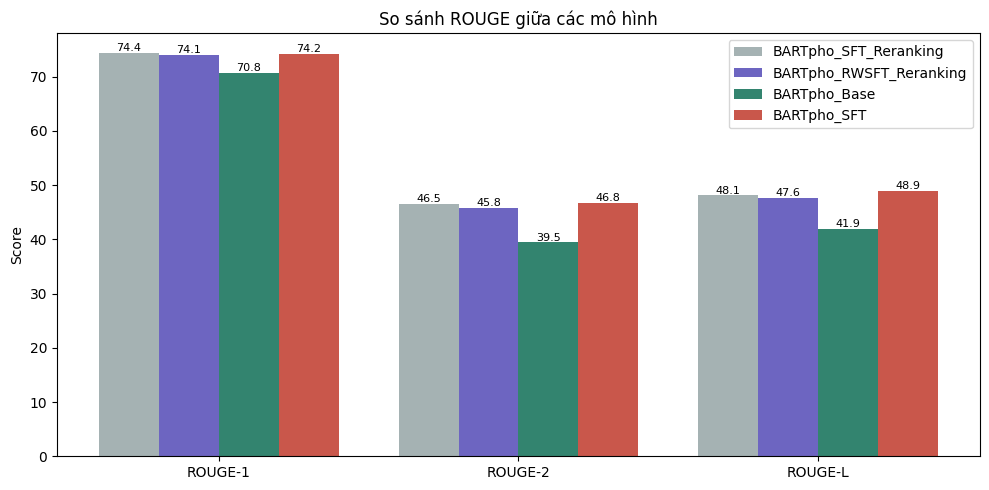

In [10]:
from rouge_score import rouge_scorer as _rs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_scorer = _rs.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

def compute_rouge(preds, refs):
    r1, r2, rl = [], [], []
    for pred, ref in zip(preds, refs):
        s = _scorer.score(str(ref), str(pred))
        r1.append(s['rouge1'].fmeasure)
        r2.append(s['rouge2'].fmeasure)
        rl.append(s['rougeL'].fmeasure)
    return {
        'ROUGE-1': round(np.mean(r1) * 100, 2),
        'ROUGE-2': round(np.mean(r2) * 100, 2),
        'ROUGE-L': round(np.mean(rl) * 100, 2),
    }

# Đánh giá trên toàn bộ test_df
refs = test_df['summary_clean'].tolist()
model_columns = [col for col in test_df.columns if col not in ['document_clean', 'summary_clean']]

rouge_rows = []
for model_name in model_columns:
    preds = test_df[model_name].tolist()
    scores = compute_rouge(preds, refs)
    scores['Model'] = model_name
    rouge_rows.append(scores)

df_rouge = pd.DataFrame(rouge_rows).set_index('Model')
print('\n===== KẾT QUẢ ROUGE =====')
print(df_rouge.to_string())
df_rouge.to_csv('rouge_results.csv')
print('\n💾 Đã lưu: rouge_results.csv')

# Vẽ biểu đồ so sánh ROUGE
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
x = np.arange(len(metrics))
width = 0.8 / len(model_columns)
colors = ['#95a5a6', '#534AB7', '#0F6E56', '#C0392B', '#E67E22']

fig, ax = plt.subplots(figsize=(10, 5))
for i, model_name in enumerate(model_columns):
    vals = [df_rouge.loc[model_name, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model_name,
                  color=colors[i % len(colors)], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{bar.get_height():.1f}',
                ha='center', fontsize=8)

ax.set_xticks(x + width * (len(model_columns) - 1) / 2)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('So sánh ROUGE giữa các mô hình')
ax.legend()
plt.tight_layout()
plt.savefig('rouge_comparison.png', dpi=150)
plt.show()


### 9.BERTScore 

⌛ Đang tính BERTScore cho: BARTpho_SFT_Reranking...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⌛ Đang tính BERTScore cho: BARTpho_RWSFT_Reranking...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⌛ Đang tính BERTScore cho: BARTpho_SFT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



===== KẾT QUẢ BERTSCORE =====
                         BERTScore-P  BERTScore-R  BERTScore-F1
Model                                                          
BARTpho_SFT_Reranking          78.11        78.49         78.28
BARTpho_RWSFT_Reranking        77.46        78.07         77.74
BARTpho_Base                   74.24        75.09         74.64
BARTpho_SFT                    78.44        78.73         78.56

💾 Đã lưu: bertscore_results.csv


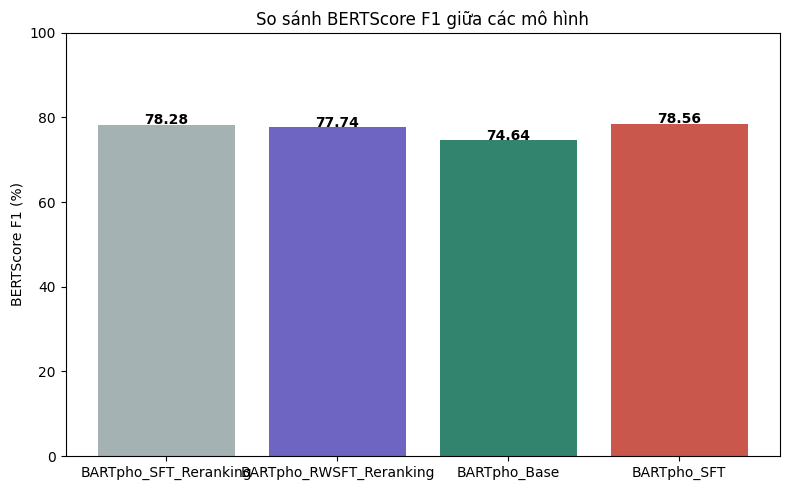


Đã xuất kết quả vào: full_evaluation_results.xlsx


In [11]:
from bert_score import score as bert_score_fn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Đánh giá trên toàn bộ test_df
refs = test_df['summary_clean'].tolist()
model_columns = [col for col in test_df.columns if col not in ['document_clean', 'summary_clean']]

bert_rows = []
for model_name in model_columns:
    preds = test_df[model_name].tolist()
    print(f'⌛ Đang tính BERTScore cho: {model_name}...')
    P, R, F1 = bert_score_fn(
        preds, refs,
        lang='vi',
        model_type='bert-base-multilingual-cased',
        verbose=False
    )
    bert_rows.append({
        'Model': model_name,
        'BERTScore-P':  round(P.mean().item() * 100, 2),
        'BERTScore-R':  round(R.mean().item() * 100, 2),
        'BERTScore-F1': round(F1.mean().item() * 100, 2),
    })

df_bert = pd.DataFrame(bert_rows).set_index('Model')
print('\n===== KẾT QUẢ BERTSCORE =====')
print(df_bert.to_string())
df_bert.to_csv('bertscore_results.csv')
print('\n💾 Đã lưu: bertscore_results.csv')

# Vẽ biểu đồ BERTScore F1
colors = ['#95a5a6', '#534AB7', '#0F6E56', '#C0392B', '#E67E22']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df_bert.index,
              df_bert['BERTScore-F1'],
              color=colors[:len(df_bert)],
              alpha=0.85)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f'{bar.get_height():.2f}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('BERTScore F1 (%)')
ax.set_title('So sánh BERTScore F1 giữa các mô hình')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('bertscore_comparison.png', dpi=150)
plt.show()

# Tổng hợp tất cả bảng kết quả vào 1 file Excel (phục hồi cả ROUGE, BERTScore và G-Eval)
with pd.ExcelWriter('full_evaluation_results.xlsx') as writer:
    df_rouge.to_excel(writer, sheet_name='ROUGE')
    df_bert.to_excel(writer, sheet_name='BERTScore')
    if 'df_ieee_style' in globals():
        df_ieee_style.to_excel(writer, sheet_name='G-Eval')
print('\nĐã xuất kết quả vào: full_evaluation_results.xlsx')


In [ ]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def compute_bleu(preds, refs):
    """
    Tính toán BLEU-1, BLEU-2, BLEU-3, BLEU-4 trên toàn bộ corpus.
    Tự động ép kiểu chuỗi và xử lý split() để tránh lỗi dữ liệu trống.
    """
    tokenized_preds = [str(pred).split() for pred in preds]
    tokenized_refs = [[str(ref).split()] for ref in refs]
    
    chencherry = SmoothingFunction()
    
    bleu1 = corpus_bleu(tokenized_refs, tokenized_preds, weights=(1.0, 0, 0, 0), smoothing_function=chencherry.method1) * 100
    bleu2 = corpus_bleu(tokenized_refs, tokenized_preds, weights=(0.5, 0.5, 0, 0), smoothing_function=chencherry.method1) * 100
    bleu3 = corpus_bleu(tokenized_refs, tokenized_preds, weights=(0.33, 0.33, 0.33, 0), smoothing_function=chencherry.method1) * 100
    bleu4 = corpus_bleu(tokenized_refs, tokenized_preds, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=chencherry.method1) * 100
    
    return {
        "BLEU-1": round(bleu1, 2),
        "BLEU-2": round(bleu2, 2),
        "BLEU-3": round(bleu3, 2),
        "BLEU-4": round(bleu4, 2)
    }

# 1. Chuẩn bị dữ liệu refs và các cột mô hình
refs = test_df['summary_clean'].tolist()
model_columns = [col for col in test_df.columns if col not in ['document_clean', 'summary_clean']]

# 2. Tính toán BLEU cho từng mô hình
bleu_rows = []
for model_name in model_columns:
    print(f"⌛ Đang tính BLEU cho mô hình: {model_name}...")
    preds = test_df[model_name].tolist()
    scores = compute_bleu(preds, refs)
    scores['Model'] = model_name
    bleu_rows.append(scores)

# 3. Tạo DataFrame kết quả và in ra
df_bleu = pd.DataFrame(bleu_rows).set_index('Model')
print('\n===== KẾT QUẢ BLEU =====')
print(df_bleu.to_string())

# 4. Lưu kết quả ra CSV
df_bleu.to_csv('bleu_results.csv')
print('\n💾 Đã lưu kết quả tại: bleu_results.csv')

# 5. Vẽ biểu đồ so sánh BLEU
metrics = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
x = np.arange(len(metrics))
width = 0.8 / len(model_columns)
colors = ['#95a5a6', '#534AB7', '#0F6E56', '#C0392B', '#E67E22']

fig, ax = plt.subplots(figsize=(10, 5))
for i, model_name in enumerate(model_columns):
    vals = [df_bleu.loc[model_name, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model_name,
                  color=colors[i % len(colors)], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{bar.get_height():.1f}',
                ha='center', fontsize=8)

ax.set_xticks(x + width * (len(model_columns) - 1) / 2)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('So sánh BLEU giữa các mô hình')
ax.legend()
plt.tight_layout()
plt.savefig('bleu_comparison.png', dpi=150)
plt.show()
